# 04 — Audio Classification Improvements

Dans le notebook précédent, nous avons construit une première baseline de classification audio sur cinq classes du dataset ESC-50.

Le pipeline utilisé était :

```text
Audio
→ MFCC
→ moyenne et écart-type
→ standardisation
→ k-NN
→ prédiction

## Objectifs du notebook

À la fin de ce notebook, nous saurons :

- comparer plusieurs configurations d’un modèle ;
- éviter de choisir un hyperparamètre uniquement sur le jeu de test ;
- utiliser les cinq folds officiels d’ESC-50 ;
- calculer une performance moyenne sur plusieurs folds ;
- extraire des caractéristiques audio plus riches ;
- comparer k-NN avec un autre classifieur ;
- sélectionner une meilleure baseline de classification audio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

from pathlib import Path

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

## 1. Chargement du dataset ESC-50

Nous allons réutiliser le même sous-ensemble de cinq classes que dans le notebook précédent.

Le dataset complet reste stocké localement dans le dossier `data/ESC-50`, qui est exclu du dépôt GitHub.

In [2]:
dataset_path = Path("data/ESC-50")
metadata_path = dataset_path / "meta" / "esc50.csv"
audio_directory = dataset_path / "audio"

metadata = pd.read_csv(metadata_path)

selected_classes = [
    "dog",
    "rain",
    "crying_baby",
    "clock_tick",
    "helicopter"
]

subset = metadata[
    metadata["category"].isin(selected_classes)
].copy()

subset["audio_path"] = subset["filename"].apply(
    lambda filename: audio_directory / filename
)

print("Shape du sous-ensemble :", subset.shape)
print("\nRépartition des classes :")
print(subset["category"].value_counts())
print("\nRépartition des folds :")
print(subset["fold"].value_counts().sort_index())

Shape du sous-ensemble : (200, 8)

Répartition des classes :
category
dog            40
helicopter     40
rain           40
crying_baby    40
clock_tick     40
Name: count, dtype: int64

Répartition des folds :
fold
1    40
2    40
3    40
4    40
5    40
Name: count, dtype: int64


## 2. Extraction de caractéristiques enrichies

Dans le notebook précédent, chaque audio était représenté par :

- la moyenne des 13 MFCC ;
- l’écart-type des 13 MFCC.

Nous allons maintenant ajouter :

- les delta MFCC, qui décrivent les variations temporelles ;
- les delta-delta MFCC, qui décrivent les variations de ces variations.

Pour chaque représentation, nous calculerons la moyenne et l’écart-type.

Chaque audio sera donc représenté par 78 caractéristiques.

In [3]:
def extract_extended_features(
    audio_path,
    target_sample_rate=16000,
    n_mfcc=13
):
    audio, _ = librosa.load(
        audio_path,
        sr=target_sample_rate,
        mono=True
    )

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=target_sample_rate,
        n_mfcc=n_mfcc
    )

    delta = librosa.feature.delta(mfcc)
    delta_delta = librosa.feature.delta(
        mfcc,
        order=2
    )

    feature_groups = [
        mfcc,
        delta,
        delta_delta
    ]

    features = []

    for feature_group in feature_groups:
        features.extend(
            feature_group.mean(axis=1)
        )
        features.extend(
            feature_group.std(axis=1)
        )

    return np.array(
        features,
        dtype=np.float32
    )

In [4]:
test_features = extract_extended_features(
    subset.iloc[0]["audio_path"]
)

print("Shape :", test_features.shape)
print("Type :", test_features.dtype)
print("Valeurs finies :", np.isfinite(test_features).all())

Shape : (78,)
Type : float32
Valeurs finies : True


## 3. Extraction des caractéristiques enrichies du dataset

Nous allons appliquer la fonction à l’ensemble des 200 fichiers.

Pour chaque audio, nous conserverons :

- son vecteur de 78 caractéristiques ;
- sa catégorie ;
- son fold ESC-50.

Le résultat pourra ensuite être utilisé pour comparer plusieurs modèles et plusieurs folds.

In [5]:
features_list = []
labels_list = []
folds_list = []

for _, row in subset.iterrows():
    features = extract_extended_features(
        row["audio_path"]
    )

    features_list.append(features)
    labels_list.append(row["category"])
    folds_list.append(row["fold"])

X_extended = np.array(features_list)
y = np.array(labels_list)
folds = np.array(folds_list)

print("Shape de X_extended :", X_extended.shape)
print("Shape de y :", y.shape)
print("Shape des folds :", folds.shape)
print("Valeurs finies :", np.isfinite(X_extended).all())

Shape de X_extended : (200, 78)
Shape de y : (200,)
Shape des folds : (200,)
Valeurs finies : True


## 4. Validation croisée sur les cinq folds

Nous allons maintenant tester plusieurs valeurs de `k`.

Pour chaque fold :

- un fold sert de jeu de test ;
- les quatre autres servent à l’entraînement ;
- le scaler est ajusté uniquement sur les données d’entraînement ;
- le modèle est ensuite évalué sur le fold laissé de côté.

Nous calculerons ensuite la moyenne des accuracies obtenues sur les cinq folds.

In [6]:
k_values = [1, 3, 5, 7, 9, 11]

knn_results = {}

for k in k_values:
    fold_accuracies = []

    for test_fold in sorted(np.unique(folds)):
        train_mask = folds != test_fold
        test_mask = folds == test_fold

        X_train = X_extended[train_mask]
        X_test = X_extended[test_mask]

        y_train = y[train_mask]
        y_test = y[test_mask]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = KNeighborsClassifier(
            n_neighbors=k
        )

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        fold_accuracies.append(accuracy)

    knn_results[k] = fold_accuracies

for k, scores in knn_results.items():
    print(
        f"k = {k:2d} | "
        f"Accuracy moyenne = {np.mean(scores):.2%} | "
        f"Écart-type = {np.std(scores):.2%}"
    )

k =  1 | Accuracy moyenne = 74.50% | Écart-type = 5.57%
k =  3 | Accuracy moyenne = 78.00% | Écart-type = 2.92%
k =  5 | Accuracy moyenne = 77.50% | Écart-type = 4.74%
k =  7 | Accuracy moyenne = 70.50% | Écart-type = 5.79%
k =  9 | Accuracy moyenne = 69.00% | Écart-type = 3.39%
k = 11 | Accuracy moyenne = 71.50% | Écart-type = 4.64%


## 5. Comparaison visuelle des valeurs de k

Nous allons représenter l’accuracy moyenne obtenue pour chaque valeur de `k`.

Les barres d’erreur correspondent à l’écart-type des performances sur les cinq folds.

Une bonne configuration doit présenter :

- une accuracy moyenne élevée ;
- une variabilité faible entre les folds.

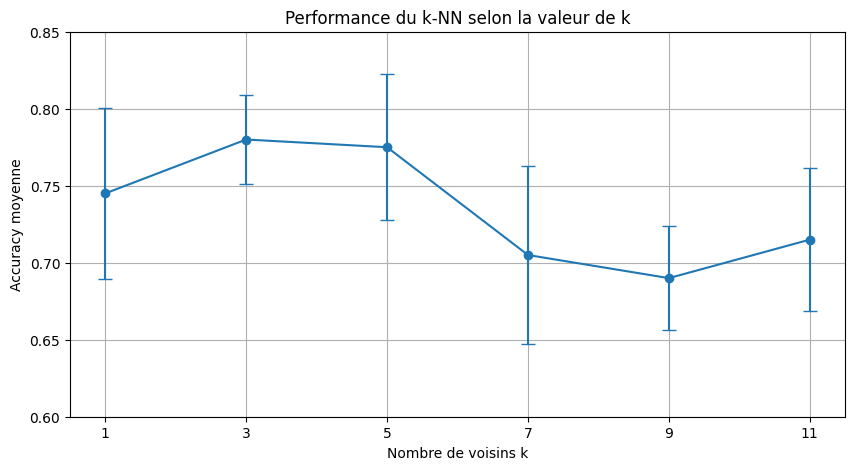

In [7]:
mean_accuracies = [
    np.mean(knn_results[k])
    for k in k_values
]

std_accuracies = [
    np.std(knn_results[k])
    for k in k_values
]

plt.figure(figsize=(10, 5))

plt.errorbar(
    k_values,
    mean_accuracies,
    yerr=std_accuracies,
    marker="o",
    capsize=5
)

plt.title("Performance du k-NN selon la valeur de k")
plt.xlabel("Nombre de voisins k")
plt.ylabel("Accuracy moyenne")
plt.xticks(k_values)
plt.ylim(0.6, 0.85)
plt.grid(True)
plt.show()

### Interprétation

La valeur `k = 3` obtient la meilleure accuracy moyenne avec 78 %.

Elle présente également l’écart-type le plus faible, ce qui indique que ses performances sont relativement stables entre les cinq folds.

Lorsque `k` devient trop grand, les voisins de classes différentes sont davantage mélangés, ce qui réduit la capacité du modèle à distinguer certaines catégories.

Nous retiendrons donc `k = 3` comme meilleure configuration k-NN pour la suite du notebook.

## 6. Comparaison avec un SVM

Le k-NN classe un exemple à partir de ses voisins les plus proches.

Le SVM cherche plutôt à construire des frontières entre les classes dans l’espace des caractéristiques.

Nous allons utiliser un SVM avec un noyau RBF, adapté aux séparations non linéaires.

Comme pour le k-NN, nous évaluerons le modèle sur les cinq folds officiels d’ESC-50.

In [8]:
svm_accuracies = []
svm_f1_scores = []

for test_fold in sorted(np.unique(folds)):
    train_mask = folds != test_fold
    test_mask = folds == test_fold

    X_train = X_extended[train_mask]
    X_test = X_extended[test_mask]

    y_train = y[train_mask]
    y_test = y[test_mask]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm_model = SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    )

    svm_model.fit(
        X_train_scaled,
        y_train
    )

    y_pred = svm_model.predict(
        X_test_scaled
    )

    svm_accuracies.append(
        accuracy_score(y_test, y_pred)
    )

    svm_f1_scores.append(
        f1_score(
            y_test,
            y_pred,
            average="macro"
        )
    )

print(
    f"Accuracy moyenne SVM : "
    f"{np.mean(svm_accuracies):.2%}"
)

print(
    f"Écart-type accuracy : "
    f"{np.std(svm_accuracies):.2%}"
)

print(
    f"Macro F1 moyen : "
    f"{np.mean(svm_f1_scores):.2%}"
)

Accuracy moyenne SVM : 84.50%
Écart-type accuracy : 5.79%
Macro F1 moyen : 84.27%


## 7. Comparaison entre k-NN et SVM

Nous allons comparer les performances moyennes des deux meilleurs modèles :

- k-NN avec `k = 3` ;
- SVM avec noyau RBF.

Les barres d’erreur représentent l’écart-type des accuracies obtenues sur les cinq folds.

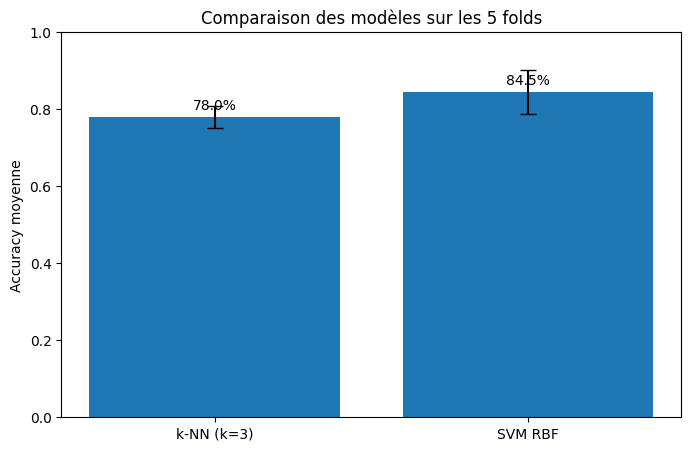

In [10]:
best_k = 3

model_names = [
    "k-NN (k=3)",
    "SVM RBF"
]

mean_scores = [
    np.mean(knn_results[best_k]),
    np.mean(svm_accuracies)
]

std_scores = [
    np.std(knn_results[best_k]),
    np.std(svm_accuracies)
]

plt.figure(figsize=(8, 5))

plt.bar(
    model_names,
    mean_scores,
    yerr=std_scores,
    capsize=6
)

plt.title("Comparaison des modèles sur les 5 folds")
plt.ylabel("Accuracy moyenne")
plt.ylim(0, 1)

for index, score in enumerate(mean_scores):
    plt.text(
        index,
        score + 0.02,
        f"{score:.1%}",
        ha="center"
    )

plt.show()

### Interprétation

Le SVM avec noyau RBF obtient la meilleure performance moyenne avec 84,5 % d’accuracy, contre 78 % pour le k-NN avec `k = 3`.

Le SVM bénéficie probablement d’une meilleure capacité à construire des frontières non linéaires dans l’espace des 78 caractéristiques.

Le k-NN reste légèrement plus stable entre les folds, mais sa performance moyenne est inférieure.

Le SVM constitue donc la meilleure baseline classique testée dans ce notebook.

## 8. Analyse des performances par fold

La moyenne globale ne montre pas comment les performances varient entre les différents folds.

Nous allons donc comparer les accuracies obtenues sur chacun des cinq folds pour :

- le k-NN avec `k = 3` ;
- le SVM avec noyau RBF.

In [11]:
fold_ids = sorted(np.unique(folds))

knn_fold_scores = knn_results[3]

comparison_df = pd.DataFrame({
    "fold": fold_ids,
    "knn_accuracy": knn_fold_scores,
    "svm_accuracy": svm_accuracies
})

comparison_df

,fold,knn_accuracy,svm_accuracy
0,1,0.725,0.800
1,2,0.775,0.775
2,3,0.800,0.825
3,4,0.800,0.900
4,5,0.800,0.925


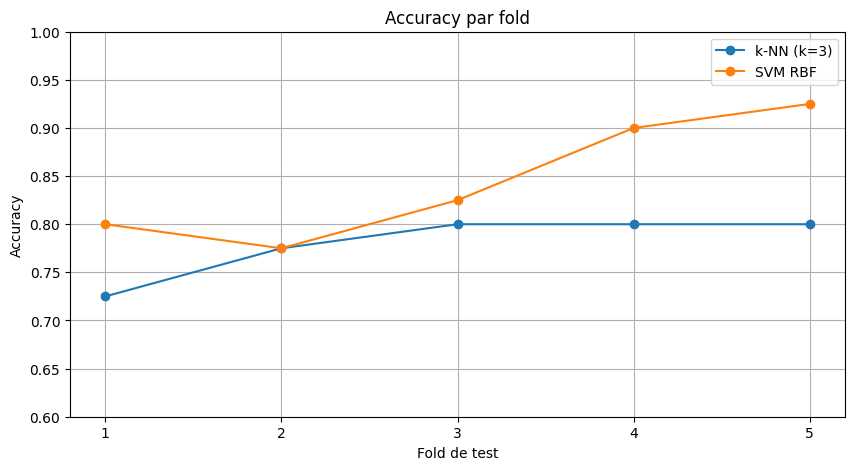

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    fold_ids,
    knn_fold_scores,
    marker="o",
    label="k-NN (k=3)"
)

plt.plot(
    fold_ids,
    svm_accuracies,
    marker="o",
    label="SVM RBF"
)

plt.title("Accuracy par fold")
plt.xlabel("Fold de test")
plt.ylabel("Accuracy")
plt.xticks(fold_ids)
plt.ylim(0.6, 1.0)
plt.grid(True)
plt.legend()
plt.show()

### Interprétation des résultats par fold

Le SVM obtient une meilleure accuracy que le k-NN sur quatre folds sur cinq.

Les deux modèles obtiennent la même performance sur le fold 2.

Le gain du SVM est particulièrement important sur les folds 4 et 5, où il atteint respectivement 90 % et 92,5 % d’accuracy.

Cependant, les performances du SVM varient davantage entre les folds. Son score passe de 77,5 % à 92,5 %, alors que le k-NN reste compris entre 72,5 % et 80 %.

Cela indique que le SVM est globalement plus performant, mais également plus sensible aux exemples présents dans chaque fold.